<a href="https://colab.research.google.com/github/Inesvvv/ML_Project/blob/main/Logistic_Regression_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Train shape: (603, 753)
Test shape: (153, 753)
Unique train groups: 201
Unique test groups: 51

===== Dummy baseline =====
Test accuracy: 0.725
Test balanced accuracy: 0.500

===== Manual CV tuning =====
C=0.001  penalty=l1 class_weight=None     -> CV ROC-AUC: 0.500 +/- 0.000 | CV Accuracy: 0.248 +/- 0.050
C=0.001  penalty=l1 class_weight=balanced -> CV ROC-AUC: 0.500 +/- 0.000 | CV Accuracy: 0.248 +/- 0.050
C=0.001  penalty=l2 class_weight=None     -> CV ROC-AUC: 0.795 +/- 0.098 | CV Accuracy: 0.704 +/- 0.054
C=0.001  penalty=l2 class_weight=balanced -> CV ROC-AUC: 0.797 +/- 0.097 | CV Accuracy: 0.675 +/- 0.059
C=0.01   penalty=l1 class_weight=None     -> CV ROC-AUC: 0.500 +/- 0.000 | CV Accuracy: 0.752 +/- 0.050
C=0.01   penalty=l1 class_weight=balanced -> CV ROC-AUC: 0.747 +/- 0.067 | CV Accuracy: 0.661 +/- 0.086
C=0.01   penalty=l2 class_weight=None     -> CV ROC-AUC: 0.781 +/- 0.064 | CV Accuracy: 0.761 +/- 0.040
C=0.01   penalty=l2 class_weight=balanced 

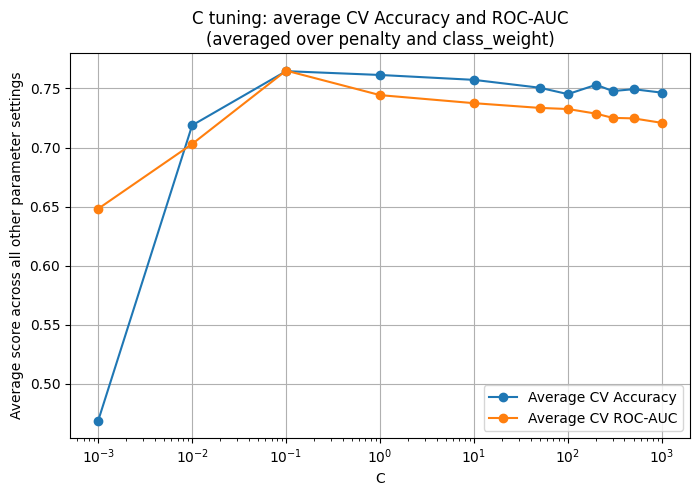


===== Averaged results for C =====
           C  cv_accuracy_mean  cv_roc_auc_mean
0      0.001          0.468963         0.648204
1      0.010          0.718770         0.702971
2      0.100          0.764593         0.765041
3      1.000          0.761362         0.744317
4     10.000          0.757226         0.737500
5     50.000          0.750579         0.733511
6    100.000          0.745163         0.732563
7    200.000          0.753069         0.728620
8    300.000          0.747734         0.725069
9    500.000          0.749350         0.724642
10  1000.000          0.746392         0.720846


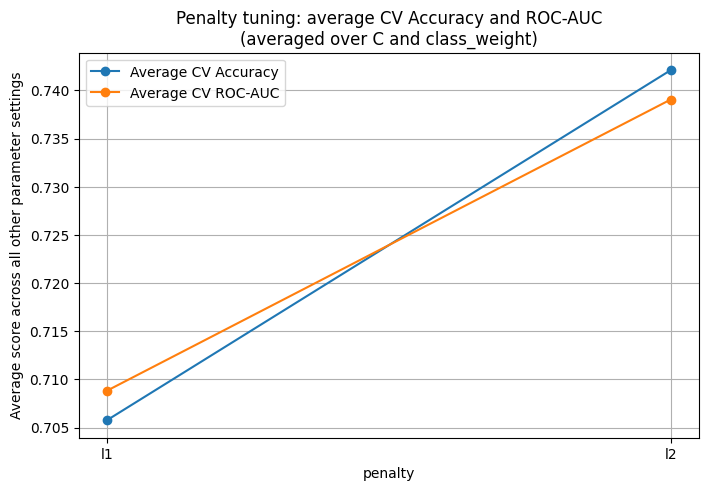


===== Averaged results for penalty =====
  penalty  cv_accuracy_mean  cv_roc_auc_mean
0      l1          0.705756         0.708819
1      l2          0.742099         0.739051


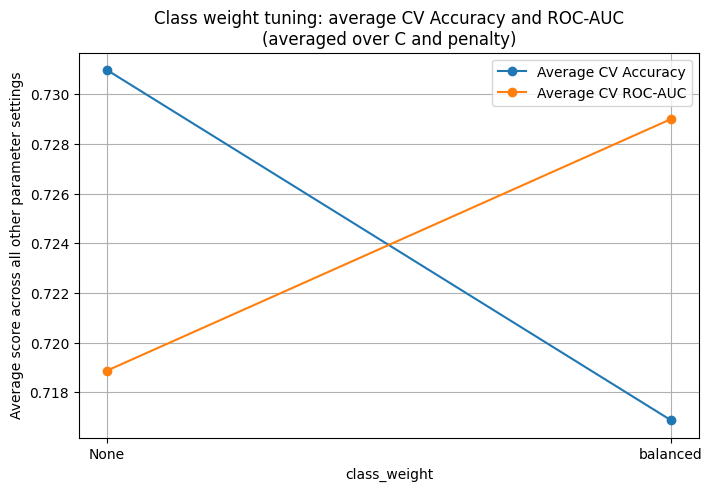


===== Averaged results for class_weight =====
  class_weight  cv_accuracy_mean  cv_roc_auc_mean
0         None          0.730974         0.718874
1     balanced          0.716881         0.728996


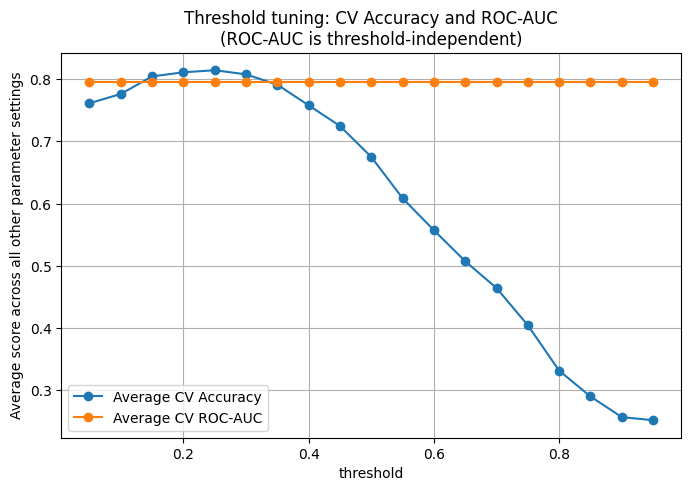


===== Averaged results for threshold =====
    threshold  cv_accuracy_mean  cv_roc_auc_mean
0        0.05          0.761194         0.794982
1        0.10          0.776119         0.794982
2        0.15          0.804312         0.794982
3        0.20          0.810945         0.794982
4        0.25          0.814262         0.794982
5        0.30          0.807629         0.794982
6        0.35          0.791045         0.794982
7        0.40          0.757877         0.794982
8        0.45          0.724710         0.794982
9        0.50          0.674959         0.794982
10       0.55          0.608624         0.794982
11       0.60          0.557214         0.794982
12       0.65          0.507463         0.794982
13       0.70          0.464345         0.794982
14       0.75          0.404643         0.794982
15       0.80          0.331675         0.794982
16       0.85          0.290216         0.794982
17       0.90          0.257048         0.794982
18       0.95          0.

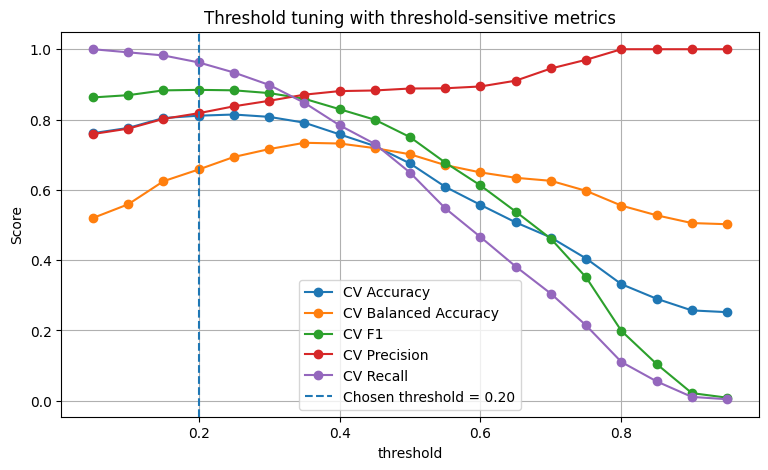

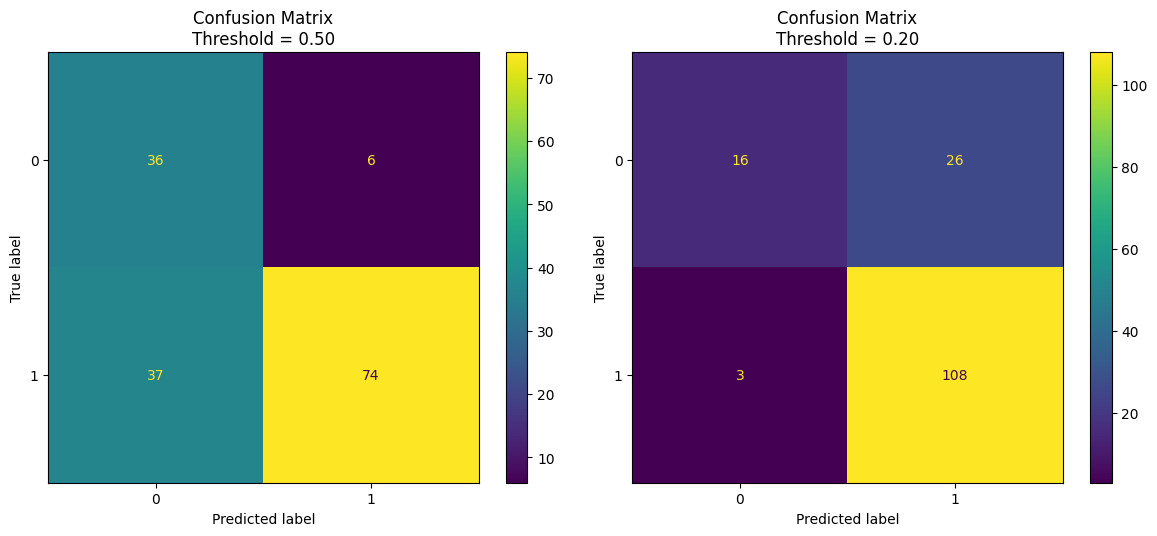


===== Full tuning table =====
           C penalty class_weight  cv_roc_auc_mean  cv_roc_auc_std  \
0      0.001      l2     balanced         0.797364        0.096908   
1      0.001      l2         None         0.795454        0.098328   
2      0.010      l2     balanced         0.783837        0.065142   
3      0.010      l2         None         0.781163        0.064376   
4      0.100      l1         None         0.776029        0.071386   
5      0.100      l1     balanced         0.775382        0.071253   
6      0.100      l2     balanced         0.755303        0.063551   
7      0.100      l2         None         0.753451        0.061252   
8      1.000      l1         None         0.752137        0.059279   
9      1.000      l1     balanced         0.751703        0.059064   
10    10.000      l1         None         0.747458        0.052672   
11     0.010      l1     balanced         0.746885        0.066871   
12    10.000      l1     balanced         0.742222        0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    cross_val_score,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# MOUNT DRIVE + LOAD DATA
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/Machine_Learning_Project/ML_notebooks/pd_speech_features.csv",
    skiprows=1
)

# features / target / groups
X = df.drop(columns=["class", "id"])
y = df["class"]
groups = df["id"]

# GROUPED TRAIN / TEST SPLIT
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
train_groups = groups.iloc[train_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Unique train groups:", train_groups.nunique())
print("Unique test groups:", groups.iloc[test_idx].nunique())

# DUMMY BASELINE
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("\n===== Dummy baseline =====")
print(f"Test accuracy: {accuracy_score(y_test, dummy_pred):.3f}")
print(f"Test balanced accuracy: {balanced_accuracy_score(y_test, dummy_pred):.3f}")

# MANUAL HYPERPARAMETER TUNING
group_kfold = GroupKFold(n_splits=5)

c_range = [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 300, 500, 1000]
penalties = ["l1", "l2"]
class_weights = [None, "balanced"]

results = []

print("\n===== Manual CV tuning =====")
for c in c_range:
    for penalty in penalties:
        for class_weight in class_weights:
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    C=c,
                    solver="liblinear",
                    penalty=penalty,
                    class_weight=class_weight,
                    max_iter=5000
                ))
            ])

            roc_scores = cross_val_score(
                pipe,
                X_train,
                y_train,
                cv=group_kfold,
                groups=train_groups,
                scoring="roc_auc"
            )

            acc_scores = cross_val_score(
                pipe,
                X_train,
                y_train,
                cv=group_kfold,
                groups=train_groups,
                scoring="accuracy"
            )

            bal_acc_scores = cross_val_score(
                pipe,
                X_train,
                y_train,
                cv=group_kfold,
                groups=train_groups,
                scoring="balanced_accuracy"
            )

            result = {
                "C": c,
                "penalty": penalty,
                "class_weight": "None" if class_weight is None else "balanced",
                "cv_roc_auc_mean": roc_scores.mean(),
                "cv_roc_auc_std": roc_scores.std(),
                "cv_accuracy_mean": acc_scores.mean(),
                "cv_accuracy_std": acc_scores.std(),
                "cv_bal_accuracy_mean": bal_acc_scores.mean(),
                "cv_bal_accuracy_std": bal_acc_scores.std()
            }

            results.append(result)

            print(
                f"C={c:<6} penalty={penalty:<2} class_weight={str(class_weight):<8} "
                f"-> CV ROC-AUC: {roc_scores.mean():.3f} +/- {roc_scores.std():.3f} | "
                f"CV Accuracy: {acc_scores.mean():.3f} +/- {acc_scores.std():.3f}"
            )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="cv_roc_auc_mean", ascending=False).reset_index(drop=True)

print("\n===== Top 10 configs by CV ROC-AUC =====")
print(results_df.head(10))

best_row = results_df.iloc[0]
print("\n===== Best configuration =====")
print(best_row)

# REBUILD BEST MODEL
best_class_weight = None if best_row["class_weight"] == "None" else "balanced"

best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=best_row["C"],
        solver="liblinear",
        penalty=best_row["penalty"],
        class_weight=best_class_weight,
        max_iter=5000
    ))
])

# THRESHOLD TUNING
train_proba_cv = cross_val_predict(
    best_pipe,
    X_train,
    y_train,
    cv=group_kfold,
    groups=train_groups,
    method="predict_proba"
)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)
constant_train_roc_auc = roc_auc_score(y_train, train_proba_cv)

threshold_results = []

for t in thresholds:
    pred_t = (train_proba_cv >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "cv_accuracy_mean": accuracy_score(y_train, pred_t),
        "cv_roc_auc_mean": constant_train_roc_auc,
        "cv_bal_accuracy_mean": balanced_accuracy_score(y_train, pred_t),
        "cv_f1_mean": f1_score(y_train, pred_t),
        "cv_precision_mean": precision_score(y_train, pred_t, zero_division=0),
        "cv_recall_mean": recall_score(y_train, pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.sort_values(by="cv_f1_mean", ascending=False).reset_index(drop=True)

print("\n===== Threshold results ranked by CV F1 =====")
print(threshold_df.head(10))

best_threshold = threshold_df.iloc[0]["threshold"]
print(f"\nChosen threshold (best CV F1): {best_threshold:.2f}")

# FINAL FIT ON FULL TRAINING SET
best_pipe.fit(X_train, y_train)

test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_pred_default = (test_proba >= 0.50).astype(int)
test_pred_best = (test_proba >= best_threshold).astype(int)

print("\n===== Final test performance =====")
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_proba):.3f}")

print("\n--- Default threshold = 0.50 ---")
print(classification_report(y_test, test_pred_default, digits=3))

print("\n--- Tuned threshold = {:.2f} ---".format(best_threshold))
print(classification_report(y_test, test_pred_best, digits=3))

# MAIN-EFFECT PLOTTING FUNCTION
# x-axis = parameter being tuned
# y-axis = average score across all other settings
def plot_main_effect(df, param_name, title, xscale_log=False):
    summary = (
        df.groupby(param_name)[["cv_accuracy_mean", "cv_roc_auc_mean"]]
        .mean()
        .reset_index()
    )

    if pd.api.types.is_numeric_dtype(summary[param_name]):
        summary = summary.sort_values(param_name)

    plt.figure(figsize=(8, 5))
    plt.plot(summary[param_name], summary["cv_accuracy_mean"], marker="o", label="Average CV Accuracy")
    plt.plot(summary[param_name], summary["cv_roc_auc_mean"], marker="o", label="Average CV ROC-AUC")

    if xscale_log:
        plt.xscale("log")

    plt.xlabel(param_name)
    plt.ylabel("Average score across all other parameter settings")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\n===== Averaged results for {param_name} =====")
    print(summary)

# GRAPHS FOR ALL PARAMETERS
# exactly in the style you asked:
# x-axis = parameter
# y-axis = accuracy and ROC-AUC averaged over all other parameters

# C
plot_main_effect(
    results_df,
    param_name="C",
    title="C tuning: average CV Accuracy and ROC-AUC\n(averaged over penalty and class_weight)",
    xscale_log=True
)

# penalty
plot_main_effect(
    results_df,
    param_name="penalty",
    title="Penalty tuning: average CV Accuracy and ROC-AUC\n(averaged over C and class_weight)"
)

# class_weight
plot_main_effect(
    results_df,
    param_name="class_weight",
    title="Class weight tuning: average CV Accuracy and ROC-AUC\n(averaged over C and penalty)"
)

# threshold
# ROC-AUC is constant across thresholds, but plotted anyway because you requested it
plot_main_effect(
    threshold_df,
    param_name="threshold",
    title="Threshold tuning: CV Accuracy and ROC-AUC\n(ROC-AUC is threshold-independent)"
)

# EXTRA THRESHOLD GRAPH
threshold_plot_df = threshold_df.sort_values("threshold")

plt.figure(figsize=(9, 5))
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["cv_accuracy_mean"], marker="o", label="CV Accuracy")
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["cv_bal_accuracy_mean"], marker="o", label="CV Balanced Accuracy")
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["cv_f1_mean"], marker="o", label="CV F1")
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["cv_precision_mean"], marker="o", label="CV Precision")
plt.plot(threshold_plot_df["threshold"], threshold_plot_df["cv_recall_mean"], marker="o", label="CV Recall")
plt.axvline(best_threshold, linestyle="--", label=f"Chosen threshold = {best_threshold:.2f}")
plt.xlabel("threshold")
plt.ylabel("Score")
plt.title("Threshold tuning with threshold-sensitive metrics")
plt.legend()
plt.grid(True)
plt.show()

# CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_default, ax=axes[0])
axes[0].set_title("Confusion Matrix\nThreshold = 0.50")

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_best, ax=axes[1])
axes[1].set_title(f"Confusion Matrix\nThreshold = {best_threshold:.2f}")

plt.tight_layout()
plt.show()

# SAVE RESULTS TABLES
print("\n===== Full tuning table =====")
print(results_df)

print("\n===== Full threshold table =====")
print(threshold_df.sort_values('threshold'))